# TP2 Multivariate extreme value theory: homework
By: Adonis Jamal

### Setup

In [1]:
!pip install MLExtreme
!pip install matplotlib>=3.8.3 networkx>=3.2.1 numpy>=2.2.3 scikit_learn>=1.4.1 scipy>=1.15.2 dcor


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import MLExtreme as mlx
# If this does not work, you may have a setup issue.
# Contact antoine.doize@sorbonne-universite.fr and provide traceback of the bug

### Warm-up questions

> a) Sous l'hypothèse nulle $H_0$, où le rayon et l'angle sont indépendants conditionnellement, la p-value suit une distribution uniforme sur l'invervalle $[0, 1]$ lorsque $n$ tend vers l'infini.


> b) En regardant la formule de $T_n$, on remarque d'abord une double sommation, donc de complexité $O((n\hat{p}_n)^2)$. Le terme suivant est une quadraple somme, mais peut s'écrire comme le produit de doubles sommes, donc de même complexité $O((n\hat{p}_n)^2)$. Finalement, le troisière terme est une triple somme, donc de complexité $O((n\hat{p}_n)^3)$. Ainsi, la complexité totale de $T_n$ est dominée par le troisième terme, et on peut conclure que la complexité de $T_n$ est d'ordre $O((n\hat{p}_n)^3)$. Cependant, il est important de noter que cette complexité peut être réduite en utilisant des techniques d'optimisation ou des structures de données appropriées pour éviter les calculs redondants.


> c) Puisqu'on doit recalculer la statistique $num\_resamples$ fois pour le test de permutation, la complexité totale pour calculer $pv_n$ est le produit de la complexité de $T_n$ par le nombre de resamples. Ainsi, la complexité totale pour calculer $pv_n$ est de l'ordre de $O(num\_resamples \cdot (n\hat{p}_n)^3)$ ou de $O(num\_resamples \cdot (n\hat{p}_n)^2)$ si des optimisations sont utilisées pour le calcul de $T_n$.


> d) Quand on effectue une analyse numérique, il est important de prendre en compte la complexité algorithmique, les conditions de moment (d'où l'utlisation de la variable aléatoire $\log(1 + U)$), et les conditions de convergence par la méthode d'estimation choisie. 

## Numerical analysis

### Model with explicit threshold

In [3]:
import numpy as np
from scipy.stats import t

def simulate_data_model_a(n=10_000, seed=42):

    rng = np.random.default_rng(seed)

    # r_{0.2}: threshold with P(R > r_{0.2}) = 0.2.
    # For R=|T|, this is the 0.9 quantile of the t(2) distribution.
    r_0_2 = t.ppf(0.9, df=2)

    R = np.abs(rng.standard_t(df=2, size=n))
    theta1 = rng.uniform(0.0, 1.0, size=n)
    theta2 = rng.beta(3.0, 3.0, size=n)
    Theta = np.where(R > r_0_2, theta1, theta2)

    X1 = R * Theta
    X2 = R * (1.0 - Theta)
    X = np.column_stack([X1, X2])
    theta1 = Theta

    return X, R, theta1, r_0_2

# Example usage
X, R, theta1, r_0_2 = simulate_data_model_a(n=10_000)

> 1. Over which threshold will there be independence of rescaled $R$ and $\Theta$?\
On obtient l'indépendance pour tout seuil $R > r_{0.2}$. Puisque $\Theta$ est défini comme $\Theta_1$ pour $R > r_{0.2}$, on ne regarde que la partie supérieure de la distribution où $\Theta = \Theta_1$, et donc on a l'indépendence. 

Le seuil théorique r_0.2 est : 1.8856


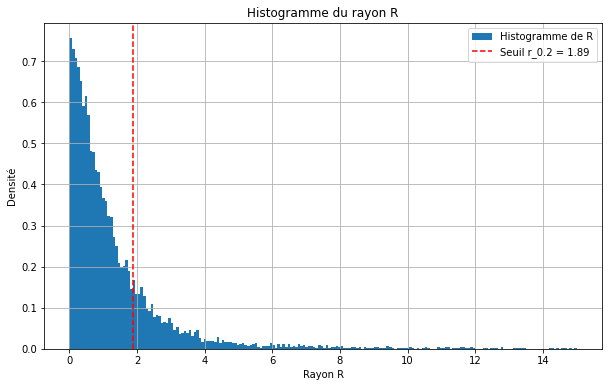

In [4]:
# 2. Histogram of the radius

from matplotlib import pyplot as plt

print(f"Le seuil théorique r_0.2 est : {r_0_2:.4f}")

plt.figure(figsize=(10, 6))
plt.hist(R, bins=200, density=True, label="Histogramme de R", range=(0, 15))
plt.axvline(x=r_0_2, color='r', linestyle='--', label=f'Seuil r_0.2 = {r_0_2:.2f}')
plt.title("Histogramme du rayon R")
plt.xlabel("Rayon R")
plt.ylabel("Densité")
plt.legend()
plt.grid()
plt.show()

100%|██████████| 20/20 [02:11<00:00,  6.59s/it]


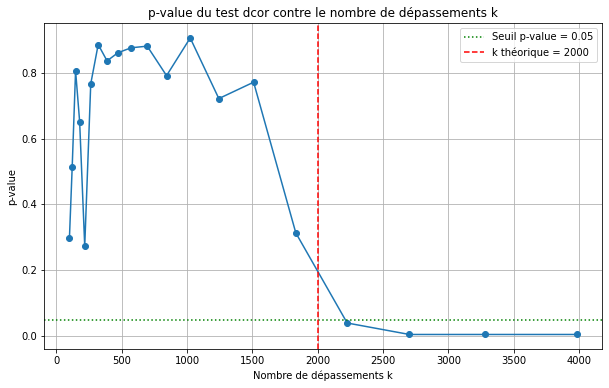

In [5]:
# 3. covariance test
from dcor.independence import distance_covariance_test
from tqdm import tqdm
R_sorted = np.sort(R)[::-1]

# k values from 100 to 4000 in log scale, to get a good coverage under 2000
k_values = np.logspace(2, 3.6, num= 20, base=10.0, dtype=int)
p_values = []
num_resamples = 200

for k in tqdm(k_values):
    threshold = R_sorted[k - 1]
    indices = np.where(R > threshold)[0]

    if len(indices) < 10:
        p_values.append(np.nan)
        continue

    R_exceed = R[indices]
    Theta_exceed = theta1[indices]

    U = np.log(1 + R_exceed / threshold)
    V = Theta_exceed

    U_matrix = U.reshape(-1, 1)
    V_matrix = V.reshape(-1, 1)

    test_result = distance_covariance_test(U_matrix, V_matrix, num_resamples=num_resamples)
    p_values.append(test_result.pvalue)

plt.figure(figsize=(10, 6))
plt.plot(k_values, p_values, marker='o', linestyle='-')
plt.axhline(0.05, color='g', linestyle=':', label='Seuil p-value = 0.05')
plt.axvline(2000, color='r', linestyle='--', label='k théorique = 2000')
plt.title("p-value du test dcor contre le nombre de dépassements k")
plt.xlabel("Nombre de dépassements k")
plt.ylabel("p-value")
plt.legend()
plt.grid()
plt.show()

> 3. Pour le choix de k, il s'agit d'un compromis en biais et variance. Si k est trop petit (seuil trop élevé), on a peu de données pour que le test soit fiable, ce qui augmente la variance de l'estimation. Si k est trop grand (seuil trop bas), on introduit un biais car on inclut des observations qui ne suivent pas la distribution asymptotique. De plus, le coût de calcul augmente fortement. Il est donc crucial de choisir k de manière à équilibrer ces deux aspects pour obtenir une estimation robuste de l'indépendance entre $R$ et $\theta$.\
C'est pour cela que nous avons choisi k entre 100 et 4000, avec une échelle logarithmique, pour couvrir une large gamme de seuils et aussi obtenir une bonne résolution dans les zones où le comportement change rapidement.

> 4. On observe que pour des seuils élevés (k faible), les p-values sont proches de 1, indiquant une forte indépendance entre $R$ et $\Theta$. Cependant, à mesure que le seuil diminue (k augmente), les p-values chutent rapidement, suggérant une dépendance croissante. Cela est cohérent avec le fait que pour des valeurs extrêmes, les variables tendent à être indépendantes, tandis que pour des valeurs moins extrêmes, des dépendances peuvent apparaître.\
A partir de k > 2000 (20% supérieur des données), on observe une baisse significative des p-values, indiquant que l'indépendance entre $R$ et $\Theta$ n'est plus maintenue. Cela suggère que le seuil critique pour l'indépendance se situe autour de ce point, ce qui est en accord avec nos attentes théoriques.

### Model with unknown theshold

In [6]:
import numpy as np

Dim = 2
n = 30000

alpha = 2 # regular variation index of the covariate
mu0 = np.geomspace(1, 2**(np.sqrt(Dim)), num=Dim)
mu0 = mu0 / np.sum(mu0)
# log-concentration parameter for Dirichlet: 
lnu = np.log(1.5/mu0.min())*np.ones(Dim)
X, _ = mlx.gen_classif_data_diriClasses(mu0=mu0, lnu=lnu,
                                        alpha=alpha,
                                        index_weight_noise=2*alpha,
                                        size=n)

100%|██████████| 20/20 [02:05<00:00,  6.28s/it]


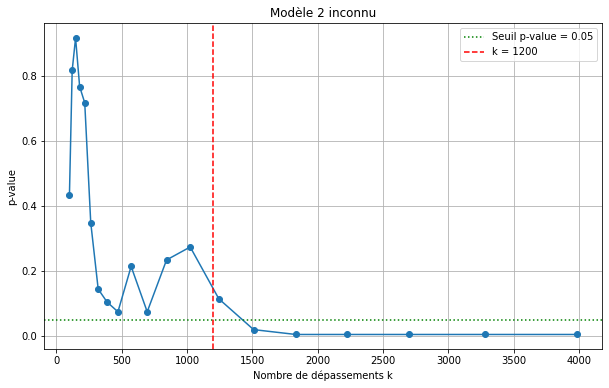

In [7]:
R_mlx = np.linalg.norm(X, ord=1, axis=1)
Theta_mlx = X[:, 0] / R_mlx

R_sorted_mlx = np.sort(R_mlx)[::-1]

k_values_mlx = np.logspace(2, 3.6, num=20, base=10.0, dtype=int)
p_values_mlx = []
num_resamples = 200

for k in tqdm(k_values_mlx):
    threshold_mlx = R_sorted_mlx[k - 1]
    indices_mlx = np.where(R_mlx > threshold_mlx)[0]

    if len(indices_mlx) < 10:
        p_values_mlx.append(np.nan)
        continue

    R_exceed_mlx = R_mlx[indices_mlx]
    Theta_exceed_mlx = Theta_mlx[indices_mlx]

    U_mlx = np.log(1 + R_exceed_mlx / threshold_mlx)
    V_mlx = Theta_exceed_mlx

    U_matrix_mlx = U_mlx.reshape(-1, 1)
    V_matrix_mlx = V_mlx.reshape(-1, 1)

    test_result_mlx = distance_covariance_test(U_matrix_mlx, V_matrix_mlx, num_resamples=num_resamples)
    p_values_mlx.append(test_result_mlx.pvalue)

plt.figure(figsize=(10, 6))
plt.plot(k_values_mlx, p_values_mlx, marker='o', linestyle='-')
plt.axhline(0.05, color='g', linestyle=':', label='Seuil p-value = 0.05')
plt.axvline(1200, color='r', linestyle='--', label='k = 1200')
plt.title("Modèle 2 inconnu")
plt.xlabel("Nombre de dépassements k")
plt.ylabel("p-value")
plt.legend()
plt.grid()
plt.show()

> 2. On obtient un seuil beaucoup plus faible, autour de $k = 1200$ (5% supérieur des données), pour lequel l'indépendance entre $R$ et $\Theta$ n'est plus maintenue. Cela peut s'expliquer par le fait que le modèle avec seuil inconnu ajuste mieux les données, capturant ainsi des dépendances qui n'étaient pas apparentes avec le modèle à seuil explicite. De plus, l'estimation du seuil peut introduire une variabilité supplémentaire, affectant la p-value du test d'indépendance.\
Par ailleurs, on remarque une chute importante avant une reaugmentation des p-values autour de k = 500. Cela peut être dû à des fluctuations aléatoires dans les données ou à des effets de bord liés à l'estimation du seuil. Il serait intéressant d'examiner plus en détail cette région pour comprendre les causes sous-jacentes de ce comportement.

### Bonus: Going further

> 1. Au lieu de calculer la distance covariance sur tous les k excédents (de cout en $k^2$), on tire un sous-échantillon de taille $m << k$. Le cout devient alors $O(m^2)$, ce qui est constant et ne grandit pas avec k. Cela donc permet d'explorer des valeurs de k plus grandes sans augmenter significativement le coût de calcul.\
La nouvelle complexité totale pour calculer $pv_n$ devient donc $O(num\_resamples \cdot m^2)$, où m est la taille du sous-échantillon choisi.

In [8]:
# implementation
def subsampled_pvalues(R_data, Theta_data, n_total, k_values, m=60, L=200, n_0=500, seed=0):
    rng = np.random.default_rng(seed)

    R_sorted = np.sort(R_data)[::-1]
    avg_p_values = []

    for k in tqdm(k_values):
        q_k = k / n_total
        n_k = int(500 * q_k)

        threshold = R_sorted[k - 1]
        indices = np.where(R_data > threshold)[0]

        if n_k < 20:
            avg_p_values.append(np.nan)
            continue

        if len(indices) < 10:
            avg_p_values.append(np.nan)
            continue

        R_exceed = R_data[indices]
        Theta_exceed = Theta_data[indices]

        m_pvalues = []

        for _ in range(m):
            sub_indices = rng.choice(len(indices), size=n_k, replace=True)

            R_subsample = R_exceed[sub_indices]
            Theta_subsample = Theta_exceed[sub_indices]

            U_subsample = np.log(1 + R_subsample / threshold)
            V_subsample = Theta_subsample

            U_matrix_subsample = U_subsample.reshape(-1, 1)
            V_matrix_subsample = V_subsample.reshape(-1, 1)

            test_result_subsample = distance_covariance_test(U_matrix_subsample, V_matrix_subsample, num_resamples=L)
            m_pvalues.append(test_result_subsample.pvalue)

        avg_p_value = np.mean(m_pvalues)
        avg_p_values.append(avg_p_value)

    return avg_p_values

n_total = 10_000
k_values_subsampled = np.logspace(2, 4, num=150, base=10.0, dtype=int)
p_values_subsampled = subsampled_pvalues(R, theta1, n_total, k_values_subsampled)
p_values_subsampled_mlx = subsampled_pvalues(R_mlx, Theta_mlx, n_total, k_values_subsampled)

100%|██████████| 150/150 [11:38<00:00,  4.66s/it]


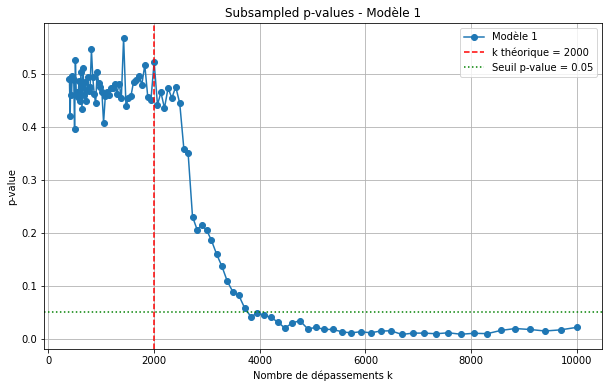

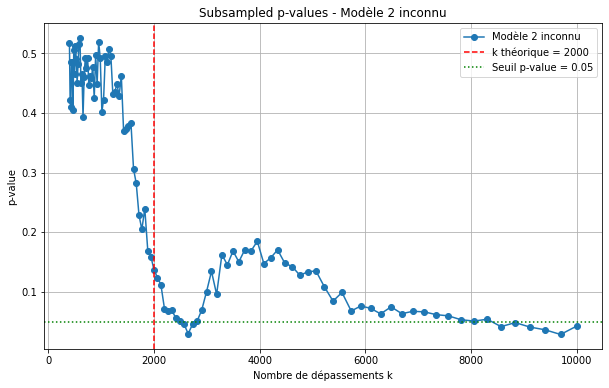

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(k_values_subsampled, p_values_subsampled, marker='o', linestyle='-', label='Modèle 1')
plt.axvline(2000, color='r', linestyle='--', label='k théorique = 2000')
plt.axhline(0.05, color='g', linestyle=':', label='Seuil p-value = 0.05')
plt.title("Subsampled p-values - Modèle 1")
plt.xlabel("Nombre de dépassements k")
plt.ylabel("p-value")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(k_values_subsampled, p_values_subsampled_mlx, marker='o', linestyle='-', label='Modèle 2 inconnu')
plt.axvline(2000, color='r', linestyle='--', label='k théorique = 2000')
plt.axhline(0.05, color='g', linestyle=':', label='Seuil p-value = 0.05')
plt.title("Subsampled p-values - Modèle 2 inconnu")
plt.xlabel("Nombre de dépassements k")
plt.ylabel("p-value")
plt.legend()
plt.grid()
plt.show()